# Money Craft: Insights

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

graph_colours = ['#6C2BD9', '#8B5CF6',"#2DD4BF"]
title_label_colour = '#211A3B'

plt.rcParams['figure.facecolor'] = '#F6F4FC' # Outer figure background
plt.rcParams['axes.facecolor'] = '#F6F4FC'    # Inner plot background
plt.rcParams['savefig.facecolor'] = '#F6F4FC'

In [2]:
scv = pd.read_csv('moneycraft_customer_view.csv')

scv.head(10)

,customer_id,signup_month,last_active,close_month,reason_code,tenure_months,channel,region,age_band,promo,first_account_tier,last_account_tier,max_fee,total_revenue,churned
0,1,2022-01,2022-06,2022-07,Switched provider,6,Comparison Site,Scotland,25-34,False,Classic,Classic,0,0,True
1,2,2022-01,2024-12,NaN,NaN,36,Online,London,55-64,False,Silver,Platinum,28,595,False
2,3,2022-01,2024-12,NaN,NaN,36,Branch,South East,25-34,False,Platinum,Platinum,28,848,False
3,4,2022-01,2024-12,NaN,NaN,36,Referral,London,25-34,True,Silver,Silver,11,330,False
4,5,2022-01,2022-10,2022-11,Bereavement,10,Comparison Site,South East,35-44,False,Silver,Classic,11,33,True
5,6,2022-01,2024-12,NaN,NaN,36,Branch,South East,35-44,False,Gold,Gold,18,536,False
6,7,2022-01,2023-05,NaN,Unknown,17,Outbound,Scotland,45-54,False,Silver,Silver,11,187,True
7,8,2022-01,2024-12,NaN,NaN,36,Online,South East,45-54,False,Silver,Gold,18,508,False
8,9,2022-01,2024-12,NaN,NaN,36,Online,North,35-44,False,Silver,Platinum,28,563,False
9,10,2022-01,2024-12,NaN,NaN,36,Broker/IFA,Scotland,18-24,True,Gold,Platinum,28,840,False


In [3]:
scv.info()

<class 'pandas.DataFrame'>
RangeIndex: 15732 entries, 0 to 15731
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   customer_id         15732 non-null  int64
 1   signup_month        15732 non-null  str  
 2   last_active         15732 non-null  str  
 3   close_month         4023 non-null   str  
 4   reason_code         6168 non-null   str  
 5   tenure_months       15732 non-null  int64
 6   channel             15732 non-null  str  
 7   region              15732 non-null  str  
 8   age_band            15732 non-null  str  
 9   promo               15732 non-null  bool 
 10  first_account_tier  15732 non-null  str  
 11  last_account_tier   15732 non-null  str  
 12  max_fee             15732 non-null  int64
 13  total_revenue       15732 non-null  int64
 14  churned             15732 non-null  bool 
dtypes: bool(2), int64(4), str(9)
memory usage: 1.6 MB


In [4]:
scv['signup_month'] = pd.PeriodIndex(scv['signup_month'], freq='M')
scv['last_active'] = pd.PeriodIndex(scv['last_active'], freq='M')
scv['close_month'] = pd.PeriodIndex(scv['close_month'], freq='M')

Null reason codes correspond to customers who have not churned. Customers will null close_month values *may* have churned since not all of the customer ids had this information available.

In [5]:
spend = pd.read_csv('moneycraft_marketing_spend.csv')

spend.head(10)

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0
5,2022-01,Referral,1872.0
6,2022-02,Branch,7882.0
7,2022-02,Broker/IFA,1989.0
8,2022-02,Comparison Site,3266.0
9,2022-02,Online,4231.0


In [6]:
spend['month'] = pd.PeriodIndex(spend['month'], freq='M')

In [7]:
spend['year'] = pd.PeriodIndex(spend['month'], freq='Y')

### Churn Rate

In [8]:
print(f'''All customers: {scv['churned'].mean():.1%}
Paying customers: {scv[scv['max_fee'] > 0]['churned'].mean():.1%}''')

All customers: 39.2%
Paying customers: 29.3%


In [9]:
channel_grouped = scv.groupby('channel')

channel_grouped['churned'].mean().round(3)*100

channel
Branch             25.3
Broker/IFA         21.6
Comparison Site    53.4
Online             39.4
Outbound           46.1
Referral           24.5
Name: churned, dtype: float64

### Marketing Spend Insights

In [10]:
channel_spend = spend.groupby('channel')['spend_gbp'].sum()
channel_spend

channel
Branch             377567.0
Broker/IFA         195020.0
Comparison Site    182406.0
Online             269322.0
Outbound           239264.0
Referral           112021.0
Name: spend_gbp, dtype: float64

### Customer Acquisition Cost (CAC)

$$ CAC = \frac{\text{Total Marketing Expenses}}{\text{Number of New Customers Acquired}}

In [11]:
customers_per_channel = scv.groupby('channel')['customer_id'].count()
customers_per_channel

channel
Branch             2481
Broker/IFA          979
Comparison Site    4584
Online             3851
Outbound           1962
Referral           1875
Name: customer_id, dtype: int64

In [12]:
cac = (channel_spend / customers_per_channel).round(2)
cac = pd.DataFrame(cac).rename(columns={0: 'CAC'})
cac

,CAC
channel,
Branch,152.18
Broker/IFA,199.20
Comparison Site,39.79
Online,69.94
Outbound,121.95
Referral,59.74


### LTV by Channel

In [13]:
ltv = scv.groupby('channel')['total_revenue'].mean().round(2)

ltv = pd.DataFrame(ltv).rename(columns={'total_revenue': 'LTV'})
ltv

,LTV
channel,
Branch,222.45
Broker/IFA,269.79
Comparison Site,63.71
Online,127.44
Outbound,95.41
Referral,215.52


### LTV:CAC by Channel

In [21]:
ltv_cac_ratio = (ltv['LTV'] / cac['CAC']).round(2)
ltv_cac_ratio

channel
Branch             1.46
Broker/IFA         1.35
Comparison Site    1.60
Online             1.82
Outbound           0.78
Referral           3.61
dtype: float64

**Referrals** are the most cost-effective acquisition channel. 

>The mean total revenue from customers acquired via the referral channel is ~3.6x that of the cost of acquiring one customer from the referral channel.

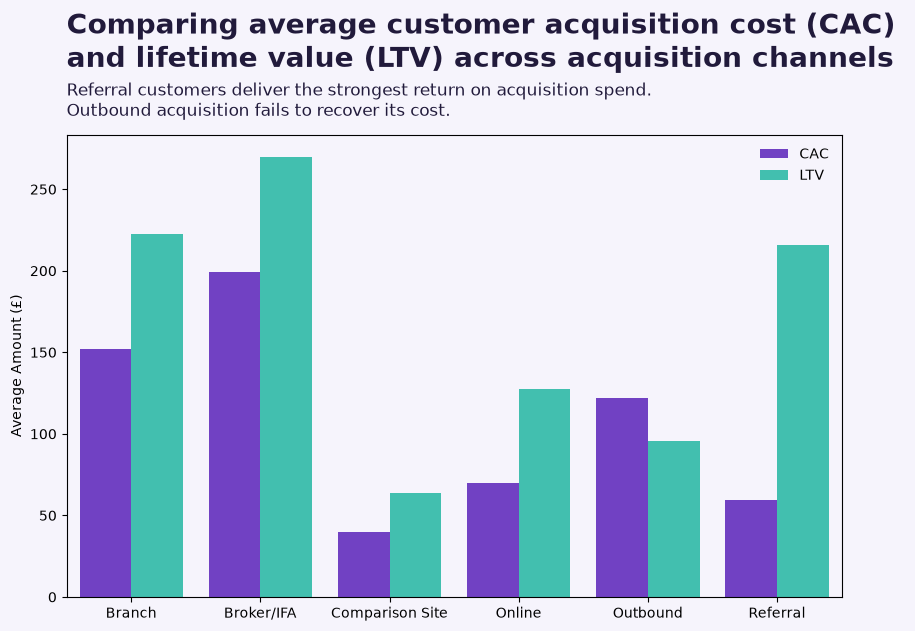

In [22]:
# df to plot LTV and CAC 
df = pd.DataFrame({
    'CAC': cac['CAC'],
    'LTV': ltv['LTV']
})

# Convert to long format
df = df.reset_index().melt(
    id_vars='channel',
    value_vars=['CAC', 'LTV'],
    var_name='Metric',
    value_name='Amount'
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='channel',
    y='Amount',
    hue='Metric',
    palette=[graph_colours[0], graph_colours[2]]
)

plt.text(-0.5, 325, '''Comparing average customer acquisition cost (CAC) 
and lifetime value (LTV) across acquisition channels''', size=20, weight='bold', color=title_label_colour)
plt.text(-0.5, 295, '''Referral customers deliver the strongest return on acquisition spend. 
Outbound acquisition fails to recover its cost.''', size=12, color=title_label_colour)
plt.xlabel('')
plt.ylabel('Average Amount (£)')
plt.legend(frameon=False)

plt.show()

C:\Users\benke\AppData\Local\Temp\ipykernel_13316\1693118300.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


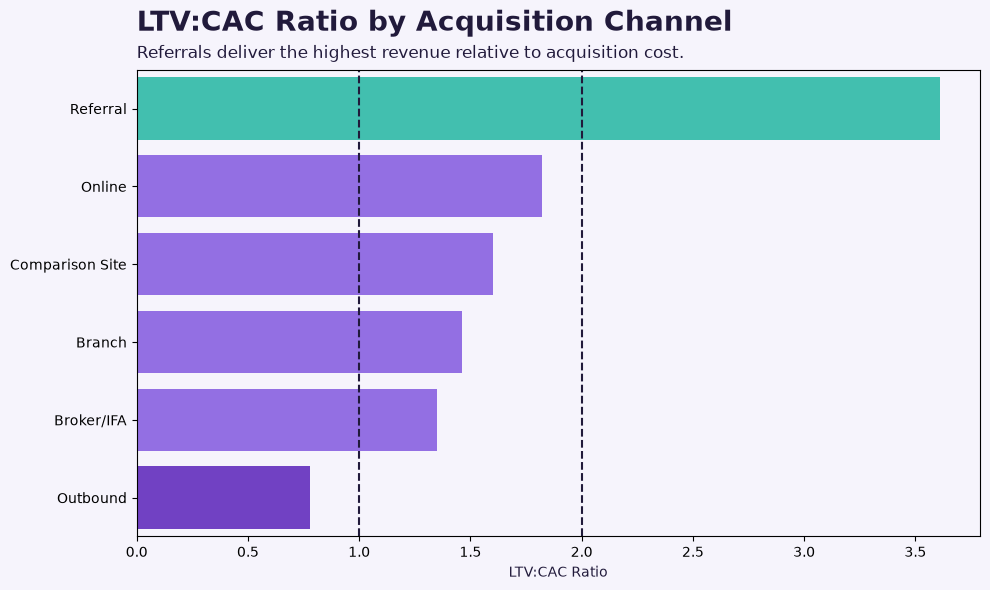

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=ltv_cac_ratio.sort_values(ascending=False),
    orient='y',
    palette=[graph_colours[2], graph_colours[1], graph_colours[1], graph_colours[1], graph_colours[1], graph_colours[0]]
)

plt.text(0, -1, 'LTV:CAC Ratio by Acquisition Channel', size=20, weight='bold', color=title_label_colour)
plt.text(0, -0.65, '''Referrals deliver the highest revenue relative to acquisition cost.''', size=12, color=title_label_colour)
plt.axvline(2, linestyle='--', color=title_label_colour)
plt.axvline(1, linestyle='--', color=title_label_colour)
plt.xlabel('LTV:CAC Ratio', color=title_label_colour)
plt.ylabel('')

plt.tight_layout()
plt.show()

## Retention Curve

In [52]:
max_t = int(scv['tenure_months'].max())

# For each month t, the share of customers still active
retention = [(scv['tenure_months'] > t).mean() for t in range(max_t)]

retention = pd.DataFrame(retention).rename(columns={0: 'proportion'})

retention[:6]   # the first few values

,proportion
0,1.000000
1,0.905797
2,0.826341
3,0.763158
4,0.707221
5,0.655225


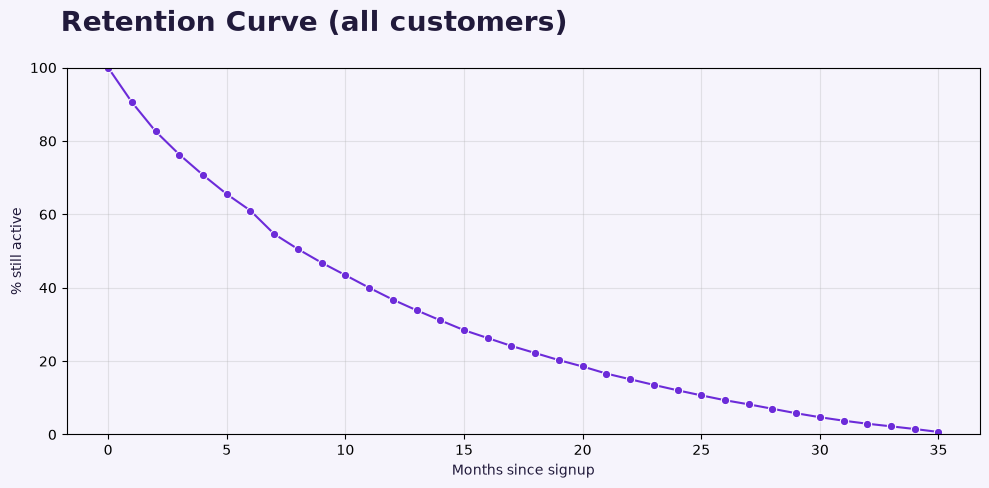

In [53]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=retention, x=range(max_t), y=[r * 100 for r in retention['proportion']], marker='o', color=graph_colours[0])

plt.text(-2, 110, 'Retention Curve (all customers)', size=20, weight='bold', color=title_label_colour)
plt.xlabel('Months since signup', color=title_label_colour)
plt.ylabel('% still active', color=title_label_colour)
plt.ylim(0, 100)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Cohort Churn

C:\Users\benke\AppData\Local\Temp\ipykernel_13316\743294708.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  sns.lineplot(data=cohort_churn, x=cohort_churn.index, y=cohort_churn.values.ravel(), marker='o', color=graph_colours[0]).set_xticklabels(labels=cohort_churn.index, rotation=70)


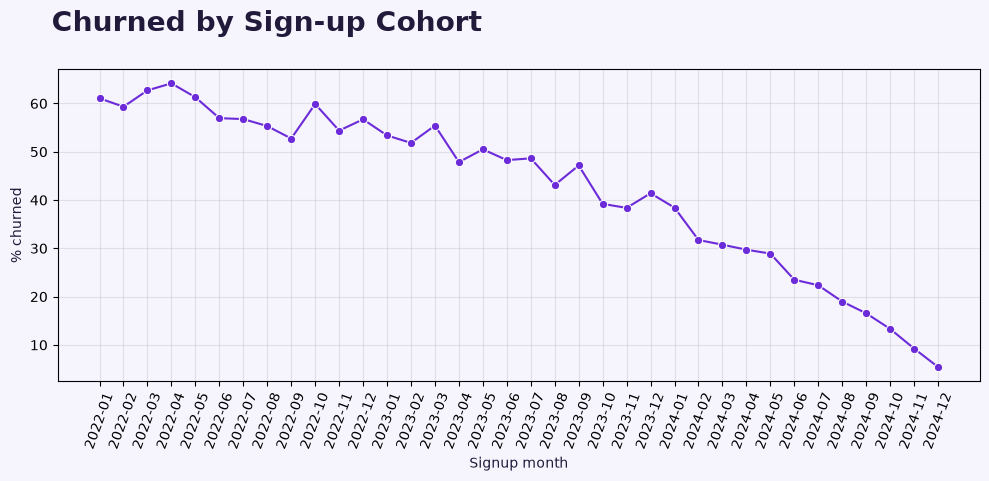

In [93]:
cohort_churn = scv.groupby('signup_month')['churned'].mean() * 100
cohort_churn = cohort_churn.to_frame()
cohort_churn.index = cohort_churn.index.astype(str) # convert index to str for plotting

plt.figure(figsize=(10, 5))
sns.lineplot(data=cohort_churn, x=cohort_churn.index, y=cohort_churn.values.ravel(), marker='o', color=graph_colours[0]).set_xticklabels(labels=cohort_churn.index, rotation=70)

plt.text(-2, 75, 'Churned by Sign-up Cohort', size=20, weight='bold', color=title_label_colour)
plt.xlabel('Signup month', color=title_label_colour)
plt.ylabel('% churned', color=title_label_colour)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 12-month Churn Indicator

In [105]:
# create a churn date column
scv['churn_date'] = scv['close_month']

mask = (
    scv['close_month'].isna() |
    (scv['last_active'] == pd.Timestamp('2024-12-01'))
)

scv.loc[mask, 'churn_date'] = scv.loc[mask, 'last_active']

scv[scv['churned'] == True].head(10)


,customer_id,signup_month,last_active,close_month,reason_code,tenure_months,channel,region,age_band,promo,first_account_tier,last_account_tier,max_fee,total_revenue,churned,churn_date
0,1,2022-01,2022-06,2022-07,Switched provider,6,Comparison Site,Scotland,25-34,False,Classic,Classic,0,0,True,2022-07
4,5,2022-01,2022-10,2022-11,Bereavement,10,Comparison Site,South East,35-44,False,Silver,Classic,11,33,True,2022-11
6,7,2022-01,2023-05,NaT,Unknown,17,Outbound,Scotland,45-54,False,Silver,Silver,11,187,True,2023-05
10,11,2022-01,2022-08,2022-09,Switched provider,8,Comparison Site,South East,18-24,True,Classic,Classic,0,0,True,2022-09
12,13,2022-01,2023-06,2023-07,Switched provider,18,Comparison Site,London,25-34,True,Classic,Classic,0,0,True,2023-07
13,14,2022-01,2024-06,NaT,Unknown,30,Online,Midlands,45-54,False,Silver,Classic,11,110,True,2024-06
14,15,2022-01,2022-01,2022-02,Fees too high,1,Branch,North,25-34,True,Silver,Silver,0,0,True,2022-02
15,16,2022-01,2022-03,2022-04,Fees too high,3,Comparison Site,London,25-34,True,Classic,Classic,0,0,True,2022-04
16,17,2022-01,2022-01,2022-02,Switched provider,1,Broker/IFA,Scotland,45-54,False,Silver,Silver,11,11,True,2022-02
17,18,2022-01,2023-01,2023-02,Poor service,13,Comparison Site,London,45-54,True,Classic,Silver,11,55,True,2023-02


In [107]:
# Churned within 12 months (365 days)
scv['churn_12m'] = (
    scv['tenure_months'] <= 12
).fillna(False)

scv[['customer_id', 'signup_month', 'churn_date', 'tenure_months', 'churn_12m']].head(10)

,customer_id,signup_month,churn_date,tenure_months,churn_12m
0,1,2022-01,2022-07,6,True
1,2,2022-01,2024-12,36,False
2,3,2022-01,2024-12,36,False
3,4,2022-01,2024-12,36,False
4,5,2022-01,2022-11,10,True
5,6,2022-01,2024-12,36,False
6,7,2022-01,2023-05,17,False
7,8,2022-01,2024-12,36,False
8,9,2022-01,2024-12,36,False
9,10,2022-01,2024-12,36,False


In [118]:
data_end = scv['last_active'].max()    

In [ ]:
# customers who signed up less than 12 months before data_end haven't had the opportunity to churn within a year, so remove them:
eligible = scv[scv['signup_month'] <= data_end - 12]